In [1]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import export_text
import matplotlib.pyplot as plt

In [4]:
# Load the Iris dataset
df = pd.read_csv('../data/iris.csv')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Fix column name issue
X = df.drop("species", axis=1) # Drop features only
y = df["species"] # Target column

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Train a Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [8]:
# Evaluate the model
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


<function matplotlib.pyplot.show(close=None, block=None)>

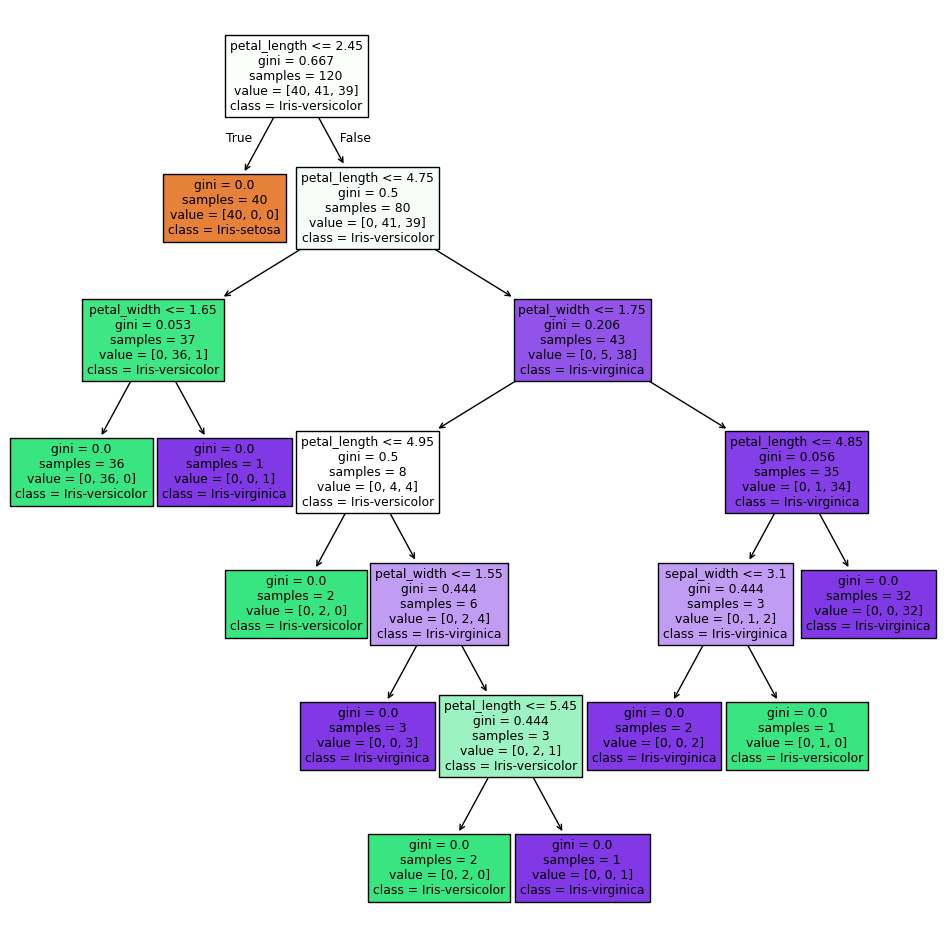

In [13]:
# Visualize the decision tree
plt.figure(figsize=(12,12))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.show

In [14]:
# Create an interactive inference interface
def make_prediction():
    """
    Interactive function to get user input and make predictions
    """
    print("=" * 50)
    print("Iris Flower Classification - Inference")
    print("=" * 50)
    
    try:
        # Get user input for the four features
        sepal_length = float(input("Enter sepal length (cm): "))
        sepal_width = float(input("Enter sepal width (cm): "))
        petal_length = float(input("Enter petal length (cm): "))
        petal_width = float(input("Enter petal width (cm): "))
        
        # Create a dataframe with the new values
        new_sample = pd.DataFrame({
            'sepal_length': [sepal_length],
            'sepal_width': [sepal_width],
            'petal_length': [petal_length],
            'petal_width': [petal_width]
        })
        
        # Make prediction
        prediction = clf.predict(new_sample)[0]
        prediction_proba = clf.predict_proba(new_sample)[0]
        
        # Display results
        print("\n" + "=" * 50)
        print("PREDICTION RESULT")
        print("=" * 50)
        print(f"Predicted Species: {prediction}")
        print("\nConfidence Scores:")
        for species, prob in zip(clf.classes_, prediction_proba):
            print(f"  {species}: {prob:.2%}")
        print("=" * 50)
        
    except ValueError:
        print("Error: Please enter valid numeric values!")

# Call the function
make_prediction()

Iris Flower Classification - Inference

PREDICTION RESULT
Predicted Species: Iris-setosa

Confidence Scores:
  Iris-setosa: 100.00%
  Iris-versicolor: 0.00%
  Iris-virginica: 0.00%
